In [526]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [527]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC,SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score


# Read the data

In [528]:
df=pd.read_csv('global-data-on-sustainable-energy (1).csv')

# 2. تحديد الترتيب الجديد للاعمدة   
new_column_order = [
    #  البيانات التعريفية والجغرافية
    'Entity', 'Year', 'Latitude', 'Longitude', 'Land Area(Km2)', 'Density\\n(P/Km2)',
    
    #  مؤشرات الوصول للطاقة
    'Access to electricity (% of population)', 'Access to clean fuels for cooking',
    
    #  مصادر وتوليد الكهرباء
    'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', 
    'Electricity from renewables (TWh)', 'Low-carbon electricity (% electricity)',
    
    #  الطاقة المتجددة والاستدامة
    'Renewable-electricity-generating-capacity-per-capita', 
    'Renewable energy share in the total final energy consumption (%)',
    'Renewables (% equivalent primary energy)', 'Financial flows to developing countries (US $)',
    
    # االاستهلاك والبيئة
    'Primary energy consumption per capita (kWh/person)', 
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
    'Value_co2_emissions_kt_by_country',
    
    #  المؤشرات الاقتصادية
    'gdp_growth', 'gdp_per_capita'
]
df = df[new_column_order]

df=pd.DataFrame(df)
df.head(10)

,Entity,Year,Latitude,Longitude,Land Area(Km2),Density\n(P/Km2),Access to electricity (% of population),Access to clean fuels for cooking,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),...,Low-carbon electricity (% electricity),Renewable-electricity-generating-capacity-per-capita,Renewable energy share in the total final energy consumption (%),Renewables (% equivalent primary energy),Financial flows to developing countries (US $),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_growth,gdp_per_capita
0,Afghanistan,2000,33.93911,67.709953,652230.0,60,1.613591,6.20,0.16,0.0,...,65.957440,9.22,44.99,NaN,20000.0,302.59482,1.64,760.000000,NaN,NaN
1,Afghanistan,2001,33.93911,67.709953,652230.0,60,4.074574,7.20,0.09,0.0,...,84.745766,8.86,45.60,NaN,130000.0,236.89185,1.74,730.000000,NaN,NaN
2,Afghanistan,2002,33.93911,67.709953,652230.0,60,9.409158,8.20,0.13,0.0,...,81.159424,8.47,37.83,NaN,3950000.0,210.86215,1.40,1029.999971,NaN,179.426579
3,Afghanistan,2003,33.93911,67.709953,652230.0,60,14.738506,9.50,0.31,0.0,...,67.021280,8.09,36.66,NaN,25970000.0,229.96822,1.40,1220.000029,8.832278,190.683814
4,Afghanistan,2004,33.93911,67.709953,652230.0,60,20.064968,10.90,0.33,0.0,...,62.921350,7.75,44.24,NaN,NaN,204.23125,1.20,1029.999971,1.414118,211.382074
5,Afghanistan,2005,33.93911,67.709953,652230.0,60,25.390894,12.20,0.34,0.0,...,63.440857,7.51,33.88,NaN,9830000.0,252.06912,1.41,1549.999952,11.229715,242.031313
6,Afghanistan,2006,33.93911,67.709953,652230.0,60,30.718690,13.85,0.20,0.0,...,76.190475,7.40,31.89,NaN,10620000.0,304.42090,1.50,1759.999990,5.357403,263.733602
7,Afghanistan,2007,33.93911,67.709953,652230.0,60,36.051010,15.30,0.20,0.0,...,78.947370,7.25,28.78,NaN,15750000.0,354.27990,1.53,1769.999981,13.826320,359.693158
8,Afghanistan,2008,33.93911,67.709953,652230.0,60,42.400000,16.70,0.19,0.0,...,73.972600,7.49,21.17,NaN,16170000.0,607.83350,1.94,3559.999943,3.924984,364.663542
9,Afghanistan,2009,33.93911,67.709953,652230.0,60,46.740050,18.40,0.16,0.0,...,82.978720,7.50,16.53,NaN,9960000.0,975.04816,2.25,4880.000114,21.390528,437.268740


# Data Exploration

In [529]:
df.columns

Index(['Entity', 'Year', 'Latitude', 'Longitude', 'Land Area(Km2)',
       'Density\n(P/Km2)', 'Access to electricity (% of population)',
       'Access to clean fuels for cooking',
       'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)',
       'Electricity from renewables (TWh)',
       'Low-carbon electricity (% electricity)',
       'Renewable-electricity-generating-capacity-per-capita',
       'Renewable energy share in the total final energy consumption (%)',
       'Renewables (% equivalent primary energy)',
       'Financial flows to developing countries (US $)',
       'Primary energy consumption per capita (kWh/person)',
       'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
       'Value_co2_emissions_kt_by_country', 'gdp_growth', 'gdp_per_capita'],
      dtype='object')

In [530]:
df.shape

(3649, 21)

In [531]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Latitude                                                          3648 non-null   float64
 3   Longitude                                                         3648 non-null   float64
 4   Land Area(Km2)                                                    3648 non-null   float64
 5   Density\n(P/Km2)                                                  3648 non-null   object 
 6   Access to electricity (% of population)                           3639 non-null   float64
 7   Access to clean fuels for cooking

In [532]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,3649.0,2.010038e+03,6.054228e+00,2000.000000,2005.000000,2.010000e+03,2.015000e+03,2.020000e+03
Latitude,3648.0,1.824639e+01,2.415923e+01,-40.900557,3.202778,1.718988e+01,3.896972e+01,6.496305e+01
Longitude,3648.0,1.482269e+01,6.634815e+01,-175.198242,-11.779889,1.914514e+01,4.619962e+01,1.780650e+02
Land Area(Km2),3648.0,6.332135e+05,1.585519e+06,21.000000,25713.000000,1.176000e+05,5.131200e+05,9.984670e+06
Access to electricity (% of population),3639.0,7.893370e+01,3.027554e+01,1.252269,59.800890,9.836157e+01,1.000000e+02,1.000000e+02
Access to clean fuels for cooking,3480.0,6.325529e+01,3.904366e+01,0.000000,23.175000,8.315000e+01,1.000000e+02,1.000000e+02
Electricity from fossil fuels (TWh),3628.0,7.036500e+01,3.480519e+02,0.000000,0.290000,2.970000e+00,2.683750e+01,5.184130e+03
Electricity from nuclear (TWh),3523.0,1.345019e+01,7.300662e+01,0.000000,0.000000,0.000000e+00,0.000000e+00,8.094100e+02
Electricity from renewables (TWh),3628.0,2.396801e+01,1.044311e+02,0.000000,0.040000,1.470000e+00,9.600000e+00,2.184940e+03
Low-carbon electricity (% electricity),3607.0,3.680118e+01,3.431488e+01,0.000000,2.877847,2.786507e+01,6.440379e+01,1.000000e+02


In [533]:
df.describe(include = 'object').T

,count,unique,top,freq
Entity,3649,176,Afghanistan,21
Density\n(P/Km2),3648,124,25,147


In [534]:
unique_values =  df.nunique()
unique_values

Entity                                                               176
Year                                                                  21
Latitude                                                             175
Longitude                                                            175
Land Area(Km2)                                                       175
Density\n(P/Km2)                                                     124
Access to electricity (% of population)                             2040
Access to clean fuels for cooking                                    896
Electricity from fossil fuels (TWh)                                 1859
Electricity from nuclear (TWh)                                       547
Electricity from renewables (TWh)                                   1533
Low-carbon electricity (% electricity)                              2647
Renewable-electricity-generating-capacity-per-capita                2110
Renewable energy share in the total final energy co

# Searching for null values & duplicate (Data Cleaning)

# Null Values

In [535]:
# Calculating the count of missing values in each column
missing_values = df.isna().sum()
missing_values

Entity                                                                 0
Year                                                                   0
Latitude                                                               1
Longitude                                                              1
Land Area(Km2)                                                         1
Density\n(P/Km2)                                                       1
Access to electricity (% of population)                               10
Access to clean fuels for cooking                                    169
Electricity from fossil fuels (TWh)                                   21
Electricity from nuclear (TWh)                                       126
Electricity from renewables (TWh)                                     21
Low-carbon electricity (% electricity)                                42
Renewable-electricity-generating-capacity-per-capita                 931
Renewable energy share in the total final energy co

In [536]:


# Creating a bar plot using Plotly Express
fig = px.bar(x=missing_values.index, y=missing_values.values, labels={'x': 'Columns', 'y': 'Missing Values Count'},
             title='Count of Missing Values in Each Column')
fig.show()

In [537]:
# Drop columns with a high number of missing values
df.drop(columns=['Financial flows to developing countries (US $)','Renewables (% equivalent primary energy)',
                 'Renewable-electricity-generating-capacity-per-capita'], inplace=True)

In [538]:
# Calculate mean for specific columns
Mean_Access = df['Access to clean fuels for cooking'].mean()
Mean_Renewable = df['Renewable energy share in the total final energy consumption (%)'].mean()
Mean_Electricity = df['Electricity from nuclear (TWh)'].mean()
Mean_Energy = df['Energy intensity level of primary energy (MJ/$2017 PPP GDP)'].mean()
Mean_Value_co2 = df['Value_co2_emissions_kt_by_country'].mean()
Mean_gdp_growth = df['gdp_growth'].mean()
Mean_gdp_per_capita = df['gdp_per_capita'].mean()

In [539]:
# Fill missing values in specific columns with calculated means
df['Access to clean fuels for cooking'].fillna(Mean_Access, inplace=True)
df['Renewable energy share in the total final energy consumption (%)'].fillna(Mean_Renewable, inplace=True)
df['Electricity from nuclear (TWh)'].fillna(Mean_Electricity, inplace=True)
df['Energy intensity level of primary energy (MJ/$2017 PPP GDP)'].fillna(Mean_Energy, inplace=True)
df['Value_co2_emissions_kt_by_country'].fillna(Mean_Value_co2, inplace=True)
df['gdp_growth'].fillna(Mean_gdp_growth, inplace=True)
df['gdp_per_capita'].fillna(Mean_gdp_per_capita, inplace=True)

# Drop rows with any remaining missing values
df = df.dropna()

# Display the shape of the DataFrame after cleaning
df.shape

(3597, 18)

In [540]:
missing_values_after = df.isna().sum()
missing_values_after

Entity                                                              0
Year                                                                0
Latitude                                                            0
Longitude                                                           0
Land Area(Km2)                                                      0
Density\n(P/Km2)                                                    0
Access to electricity (% of population)                             0
Access to clean fuels for cooking                                   0
Electricity from fossil fuels (TWh)                                 0
Electricity from nuclear (TWh)                                      0
Electricity from renewables (TWh)                                   0
Low-carbon electricity (% electricity)                              0
Renewable energy share in the total final energy consumption (%)    0
Primary energy consumption per capita (kWh/person)                  0
Energy intensity lev

# Duplicate Row

In [541]:
duplicate_rows=df.duplicated().sum()
duplicate_rows
print("Number of duplicate rows:", duplicate_rows)



Number of duplicate rows: 0


# Feature Engineering

In [542]:
# Reanme columns 
df.rename(columns={"Value_co2_emissions_kt_by_country":"CO2" , 'Land Area(Km2)':'Land'} , inplace=True)

In [543]:
df.rename(columns={'Density\\n(P/Km2)': 'Density'}, inplace=True)
df['Density'] = df['Density'].str.replace(',', '').astype(int)

In [544]:
# Selecting specific columns 'Entity' and 'Land' into a new DataFrame
energy_land = df[['Entity', 'Land']]

# Dropping rows with missing values in the selected columns
energy_land = energy_land.dropna()

# Getting unique country names from the 'Entity' column
countries = energy_land['Entity'].unique()

# Getting unique land area values from the 'Land' column
land = energy_land['Land'].unique()

# Clean the land area values by converting to integers
land_int = []
for num in land:
    if isinstance(num, float):
        land_int.append(int(num))
    else:
        land_int.append(int(str(num).replace(',', '')))

# Scale the data

In [545]:
df.head()

,Entity,Year,Latitude,Longitude,Land,Density,Access to electricity (% of population),Access to clean fuels for cooking,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Renewable energy share in the total final energy consumption (%),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),CO2,gdp_growth,gdp_per_capita
0,Afghanistan,2000,33.93911,67.709953,652230.0,60,1.613591,6.2,0.16,0.0,0.31,65.957440,44.99,302.59482,1.64,760.000000,3.441610,13283.774348
1,Afghanistan,2001,33.93911,67.709953,652230.0,60,4.074574,7.2,0.09,0.0,0.50,84.745766,45.60,236.89185,1.74,730.000000,3.441610,13283.774348
2,Afghanistan,2002,33.93911,67.709953,652230.0,60,9.409158,8.2,0.13,0.0,0.56,81.159424,37.83,210.86215,1.40,1029.999971,3.441610,179.426579
3,Afghanistan,2003,33.93911,67.709953,652230.0,60,14.738506,9.5,0.31,0.0,0.63,67.021280,36.66,229.96822,1.40,1220.000029,8.832278,190.683814
4,Afghanistan,2004,33.93911,67.709953,652230.0,60,20.064968,10.9,0.33,0.0,0.56,62.921350,44.24,204.23125,1.20,1029.999971,1.414118,211.382074


In [546]:

# Columns to be scaled
columns_to_scale = ['Electricity from fossil fuels (TWh)','CO2',
                    'Land','Electricity from nuclear (TWh)','Electricity from renewables (TWh)','Density']



# Select only the columns to be scaled
data_to_scale = df[columns_to_scale]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Scale the selected columns
scaled_data = scaler.fit_transform(data_to_scale)

# Create a new DataFrame with the scaled values
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaled_data

# Display the scaled DataFrame
df_scaled.head()


,Entity,Year,Latitude,Longitude,Land,Density,Access to electricity (% of population),Access to clean fuels for cooking,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Renewable energy share in the total final energy consumption (%),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),CO2,gdp_growth,gdp_per_capita
0,Afghanistan,2000,33.93911,67.709953,0.065321,0.006941,1.613591,6.2,0.000031,0.0,0.000142,65.957440,44.99,302.59482,1.64,0.000068,3.441610,13283.774348
1,Afghanistan,2001,33.93911,67.709953,0.065321,0.006941,4.074574,7.2,0.000017,0.0,0.000229,84.745766,45.60,236.89185,1.74,0.000065,3.441610,13283.774348
2,Afghanistan,2002,33.93911,67.709953,0.065321,0.006941,9.409158,8.2,0.000025,0.0,0.000256,81.159424,37.83,210.86215,1.40,0.000093,3.441610,179.426579
3,Afghanistan,2003,33.93911,67.709953,0.065321,0.006941,14.738506,9.5,0.000060,0.0,0.000288,67.021280,36.66,229.96822,1.40,0.000111,8.832278,190.683814
4,Afghanistan,2004,33.93911,67.709953,0.065321,0.006941,20.064968,10.9,0.000064,0.0,0.000256,62.921350,44.24,204.23125,1.20,0.000093,1.414118,211.382074


# correlation_matrix

In [547]:
## Calculate the correlation matrix by plotting a heatmap
correlation_matrix = df.corr(numeric_only=True)


import plotly.express as px

# Create a correlation heatmap using Plotly Express
fig = px.imshow(
    correlation_matrix,  # Matrix containing the data
    labels=dict(x="Features", y="Features", color="Correlation"),  # Customize labels
    x=correlation_matrix.columns,  # x-values: Features
    y=correlation_matrix.columns,  # y-values: Features
    color_continuous_scale='blues',  # Set the color scale
    title='Correlation Heatmap',  # Set the title of the plot
    height=1200  # Set the height of the plot
)

# Display the plot
fig.show()

In [548]:
print('Top 5 Most Positively Correlated to the Target Variable')
correlation_matrix['CO2'].sort_values(ascending=False).head(5)

Top 5 Most Positively Correlated to the Target Variable


CO2                                    1.000000
Electricity from fossil fuels (TWh)    0.948946
Electricity from renewables (TWh)      0.786547
Land                                   0.633147
Electricity from nuclear (TWh)         0.582749
Name: CO2, dtype: float64

In [549]:
print('Top 5 Most Negatively Correlated to the Target Variable')
correlation_matrix['CO2'].sort_values(ascending=True).head(5)

Top 5 Most Negatively Correlated to the Target Variable


Renewable energy share in the total final energy consumption (%)   -0.131661
Low-carbon electricity (% electricity)                             -0.051853
Density                                                            -0.016518
Year                                                                0.021141
gdp_growth                                                          0.028050
Name: CO2, dtype: float64

# Feature Selection (Reduce dimensionality)

In [550]:
# list of columns to protect from dropping based on correlation threshold
protected_columns = ['gdp_per_capita', 'Primary energy consumption per capita (kWh/person)', 'Year']


columns_to_drop = [
    col for col in correlation_matrix.columns 
    if abs(correlation_matrix.loc['CO2', col]) < 0.5 
    and col not in protected_columns 
    and col != 'CO2'
]

print('The number of columns to drop is:', len(columns_to_drop))
print('Columns to drop:', columns_to_drop)

The number of columns to drop is: 9
Columns to drop: ['Latitude', 'Longitude', 'Density', 'Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Low-carbon electricity (% electricity)', 'Renewable energy share in the total final energy consumption (%)', 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)', 'gdp_growth']


In [551]:

df = df.drop(columns_to_drop, axis=1)


print("Columns remaining after dropping low-correlation features:")
print(df.columns.tolist())

Columns remaining after dropping low-correlation features:
['Entity', 'Year', 'Land', 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', 'Electricity from renewables (TWh)', 'Primary energy consumption per capita (kWh/person)', 'CO2', 'gdp_per_capita']


In [552]:
df.head(10)

,Entity,Year,Land,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Primary energy consumption per capita (kWh/person),CO2,gdp_per_capita
0,Afghanistan,2000,652230.0,0.16,0.0,0.31,302.59482,760.000000,13283.774348
1,Afghanistan,2001,652230.0,0.09,0.0,0.50,236.89185,730.000000,13283.774348
2,Afghanistan,2002,652230.0,0.13,0.0,0.56,210.86215,1029.999971,179.426579
3,Afghanistan,2003,652230.0,0.31,0.0,0.63,229.96822,1220.000029,190.683814
4,Afghanistan,2004,652230.0,0.33,0.0,0.56,204.23125,1029.999971,211.382074
5,Afghanistan,2005,652230.0,0.34,0.0,0.59,252.06912,1549.999952,242.031313
6,Afghanistan,2006,652230.0,0.20,0.0,0.64,304.42090,1759.999990,263.733602
7,Afghanistan,2007,652230.0,0.20,0.0,0.75,354.27990,1769.999981,359.693158
8,Afghanistan,2008,652230.0,0.19,0.0,0.54,607.83350,3559.999943,364.663542
9,Afghanistan,2009,652230.0,0.16,0.0,0.78,975.04816,4880.000114,437.268740


In [553]:
# Scaling tha Land and Primary energy consumption per capita (kWh/person) and gdp_per_capita
scaler = MinMaxScaler()
columns_to_scale = ['Land', 'Primary energy consumption per capita (kWh/person)', 'gdp_per_capita']
data_to_scale = df[columns_to_scale]
scaled_data = scaler.fit_transform(data_to_scale)
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaled_data
df_scaled.head(10)

,Entity,Year,Land,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Primary energy consumption per capita (kWh/person),CO2,gdp_per_capita
0,Afghanistan,2000,0.065321,0.16,0.0,0.31,0.000752,760.000000,0.106739
1,Afghanistan,2001,0.065321,0.09,0.0,0.50,0.000502,730.000000,0.106739
2,Afghanistan,2002,0.065321,0.13,0.0,0.56,0.000403,1029.999971,0.000547
3,Afghanistan,2003,0.065321,0.31,0.0,0.63,0.000476,1220.000029,0.000638
4,Afghanistan,2004,0.065321,0.33,0.0,0.56,0.000378,1029.999971,0.000806
5,Afghanistan,2005,0.065321,0.34,0.0,0.59,0.000560,1549.999952,0.001054
6,Afghanistan,2006,0.065321,0.20,0.0,0.64,0.000759,1759.999990,0.001230
7,Afghanistan,2007,0.065321,0.20,0.0,0.75,0.000949,1769.999981,0.002008
8,Afghanistan,2008,0.065321,0.19,0.0,0.54,0.001915,3559.999943,0.002048
9,Afghanistan,2009,0.065321,0.16,0.0,0.78,0.003314,4880.000114,0.002636


# <div style="text-align: center; background-color: #6495ED; font-family:Times New Roman; color: white; padding: 14px; line-height: 1;border-radius:20px">7. Data visualisation</div>

# The Target Column 'CO2'

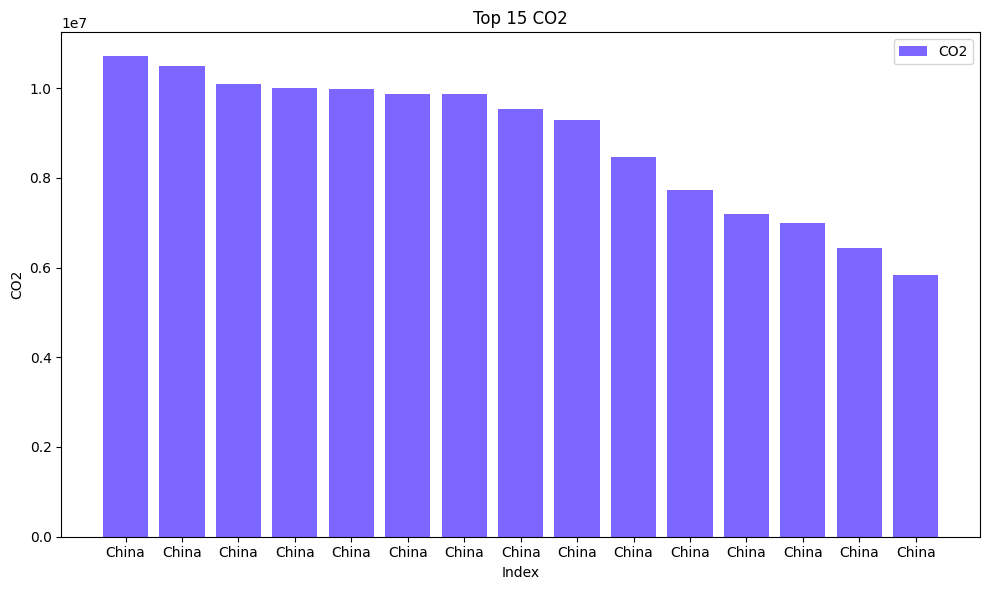

In [554]:
# the top 15 CO2 emissions by country in a bar chart
top_CO2 = df['CO2'].nlargest(15)
locations = df.loc[top_CO2.index]['Entity']

# Plotting the top 15 prices using Matplotlib
plt.figure(figsize=(10, 6))  
plt.bar(range(len(top_CO2)), top_CO2, color='#7B66FF')  
plt.xlabel('Index')  
plt.ylabel('CO2') 
plt.legend(['CO2'])
plt.title('Top 15 CO2') 
plt.xticks(range(len(top_CO2)), locations)  
plt.tight_layout()  
plt.show()

In [555]:
# Calculate the maximum 'CO2' emissions for each 'Country' category and sort in descending order
max_co2 = df.groupby('Entity')['CO2'].max().reset_index()
max_co2 = max_co2.sort_values(by='CO2', ascending=False)

# Select the top 10 'Country' categories with the highest maximum 'CO2' emissions
top_10_high_co2 = max_co2.head(10)

# Create a bar plot using Plotly Express
fig = px.bar(
    top_10_high_co2,  # DataFrame containing the data
    x='Entity',  # x-values: 'Country' categories
    y='CO2',  # y-values: maximum 'CO2' emissions
    color='CO2',  # Color the bars based on the indices
    title='Top 10 Countries by Maximum CO2 Emissions',  # Set the title of the plot
    labels={'Country': 'Country', 'CO2': 'CO2 Emissions'},  # Customize labels
    template='plotly_white'  # Use a white template for the plot
)

# Set the height of the plot
fig.update_layout(height=550)

# Display the plot
fig.show()

In [556]:
# Calculate the median 'CO2' emissions for each 'Year'
CO2_By_Year = df.groupby('Year')['CO2'].max().reset_index()

# Create a line plot using Plotly Express
fig_CO2_By_Year = px.line(
    CO2_By_Year,  # DataFrame containing the data
    x='Year',   # x-values: Year
    y='CO2',  # y-values: median CO2
    labels={'Year': 'Year'},  # Customize label for the x-axis
    title='Maxmum CO2 Emissions by Year',  # Set the title of the plot
    height=500  # Set the height of the plot
)

# Display the plot
fig_CO2_By_Year.show()

In [557]:
# distribution of CO2 emissions and highlights the presence of significant outliers in the dataset
fig1 = px.box(df_scaled, y='CO2', template='plotly_white', title='CO2 emission (BoxPlot)')

# Customize the layout of the box plot
fig1.update_layout(font=dict(size=17, family="Franklin Gothic"))

# Display the box plot
fig1.show()

In [558]:
#scatter plots visualize the relationship between CO2 emissions and various
columns_to_plot = [
    ('Electricity from fossil fuels (TWh)', 'CO2', 'CO2 emission by Electricity from fossil fuels (TWh)'),
    ('Electricity from renewables (TWh)', 'CO2', 'CO2 emission by Electricity from renewables (TWh)'),
    ('Land','CO2','CO2 emission by Land'),
    ('Electricity from nuclear (TWh)','CO2','CO2 emission by Electricity from nuclear (TWh)')
]

fig = make_subplots(rows=2, cols=2, subplot_titles=[title for _, _, title in columns_to_plot])

for i, (column, y_label, title) in enumerate(columns_to_plot, start=1):
    data = df_scaled.groupby(column)[y_label].sum().reset_index()
    
    # Add a scatter plot to the subplot
    fig.add_trace(
        go.Scatter(x=data[column], y=data[y_label], mode='markers', name=title),
        row=(i - 1) // 2 + 1,  # Calculate the subplot row
        col=(i - 1) % 2 + 1  # Calculate the subplot column
    )

# Update layout and display the plot
fig.update_layout(height=1000, width=1000, showlegend=False, title='CO2 Emissions by Various Factors')
fig.show()


In [559]:
# Calculate the Max 'CO2' for each 'Year' and sort in descending order
Max_CO2 = df.groupby('Year')['CO2'].max().reset_index()
Max_CO2 = Max_CO2.sort_values(by='CO2', ascending=False)

# Select the top 10 years with the highest CO2 emissions
top_10_expensive_CO2 = Max_CO2.head(10)

# Create a bar plot using Plotly Express
fig = px.bar(
    top_10_expensive_CO2,  # DataFrame containing the data
    x='Year',  # x-values: years
    y='CO2',  # y-values: Max CO2 emissions
    color='CO2',  # Color the bars based on the CO2 values
    title='Top 10 Years by Max CO2 Emissions',  # Set the title of the plot
    labels={'Year': 'Year', 'CO2': 'Max CO2'},  # Set labels for axes
    template='plotly_white'  # Use a white template for the plot
)

# Set font color to black
fig.update_traces(textfont_color='black')

# Set the height of the plot
fig.update_layout(height=650)

# Display the plot
fig.show()

# Electricity from fossil fuels (TWh)

In [560]:
# Calculate the max 'Entity' for each 'Electricity from fossil fuels (TWh)'
Entity_By_Electricity_from_fossil = df.groupby('Entity')['Electricity from fossil fuels (TWh)'].max().reset_index()

# Create a line plot using Plotly Express
fig_Entity_By_Electricity_from_fossil = px.line(
    Entity_By_Electricity_from_fossil,  # DataFrame containing the data
    x='Entity',   # x-values: Year
    y='Electricity from fossil fuels (TWh)',  # y-values: median Land
    labels={'Entity': 'Entity'},  # Customize label for the x-axis
    title='Entity by Electricity from fossil fuels (TWh)',  # Set the title of the plot
    height=650  # Set the height of the plot
)

# Display the plot
fig_Entity_By_Electricity_from_fossil.show()

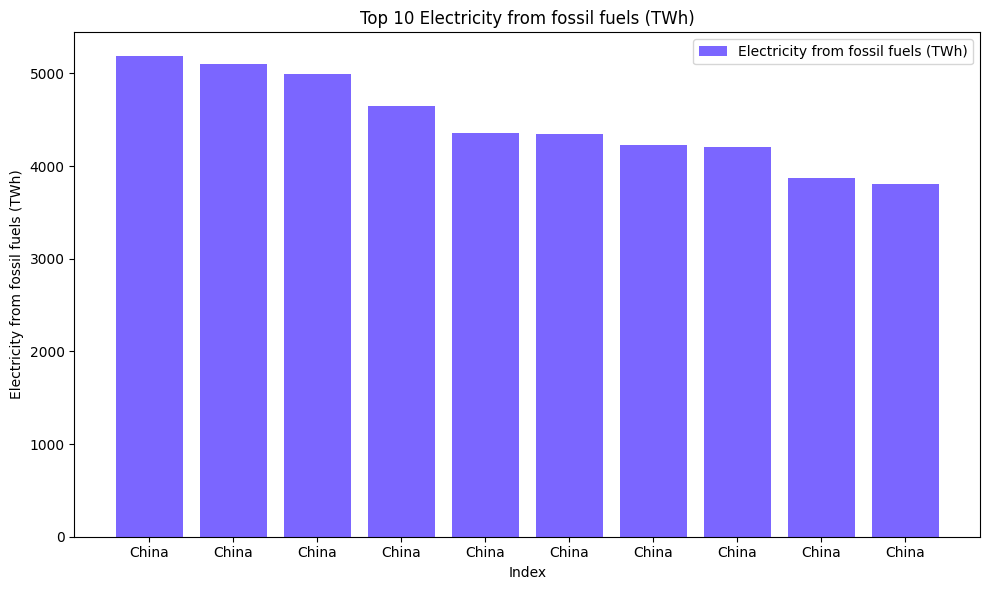

In [561]:
# Selecting the top 10 Electricity from fossil fuels (TWh) from the 'Electricity from fossil fuels (TWh)' column in the DataFrame 'df'
top_CO2 = df['Electricity from fossil fuels (TWh)'].nlargest(10)
locations = df.loc[top_CO2.index]['Entity']

# Plotting the top 10 prices using Matplotlib
plt.figure(figsize=(10, 6))  
plt.bar(range(len(top_CO2)), top_CO2, color='#7B66FF')  
plt.xlabel('Index')  
plt.ylabel('Electricity from fossil fuels (TWh)') 
plt.legend(['Electricity from fossil fuels (TWh)'])
plt.title('Top 10 Electricity from fossil fuels (TWh)') 
plt.xticks(range(len(top_CO2)), locations)  
plt.tight_layout()  
plt.show()

In [562]:
# Create the box plot using Plotly Express for 'CO2'
fig1 = px.box(df_scaled, y='Electricity from fossil fuels (TWh)', template='plotly_white', title='Electricity from fossil fuels (TWh) ')

# Customize the layout of the box plot
fig1.update_layout(font=dict(size=17, family="Franklin Gothic"))

# Display the box plot
fig1.show()

# Electricity from renewables (TWh)

In [563]:
Entity_By_Electricity = df.groupby('Entity')['Electricity from renewables (TWh)'].max().reset_index()

# Create a line plot using Plotly Express
fig_Entity_By_Electricity = px.line(
    Entity_By_Electricity,  # DataFrame containing the data
    x='Entity',   # x-values: Year
    y='Electricity from renewables (TWh)',  # y-values: median Land
    labels={'Entity': 'Entity'},  # Customize label for the x-axis
    title='Electricity from renewables (TWh)',  # Set the title of the plot
    height=650  # Set the height of the plot
)

# Display the plot
fig_Entity_By_Electricity.show()

In [564]:
# Create the box plot using Plotly Express for 'Electricity from renewables (TWh)'
fig1 = px.box(df_scaled, y='Electricity from renewables (TWh)', template='plotly_white', title='Electricity from renewables (TWh)')

# Customize the layout of the box plot
fig1.update_layout(font=dict(size=17, family="Franklin Gothic"))

# Display the box plot
fig1.show()

# Land

In [565]:
# Creating a DataFrame using the country names and cleaned land area values
energy_land_data_use_df = pd.DataFrame({'Country': countries, 'Land': land_int})

# Creating a bar plot using Plotly Express
fig = px.bar(energy_land_data_use_df, x='Country', y='Land', labels={'Land': 'Land Area - km2', 'Entity': 'Country'})

# Updating the graph layout and title
fig.update_layout(title={'text': 'Countries Land Area - in km2', 'x': 0.5})

# Displaying the graph
fig.show()

In [566]:
# Calculate the maximum 'Land' for each 'Country' category and sort in descending order
max_co2 = df.groupby('Entity')['Land'].max().reset_index()
max_co2 = max_co2.sort_values(by='Land', ascending=False)

# Select the top 10 'Country' categories with the highest maximum 'Land' 
top_10_high_co2 = max_co2.head(10)

# Create a bar plot using Plotly Express
fig = px.bar(
    top_10_high_co2,  # DataFrame containing the data
    x='Entity',  # x-values: 'Country' categories
    y='Land',  # y-values: maximum 'Land' 
    color='Land',  # Color the bars based on the indices
    title='Top 10 Countries by Land ',  # Set the title of the plot
    labels={'Country': 'Country', 'Land': 'Land'},  # Customize labels
    template='plotly_white'  # Use a white template for the plot
)

# Set the height of the plot
fig.update_layout(height=650)

# Display the plot
fig.show()

# Entity & Year 

In [567]:
energy_co2_data = df[['Entity', 'Year', 'CO2']]#create new data 
energy_co2_data.head()

,Entity,Year,CO2
0,Afghanistan,2000,760.000000
1,Afghanistan,2001,730.000000
2,Afghanistan,2002,1029.999971
3,Afghanistan,2003,1220.000029
4,Afghanistan,2004,1029.999971


In [568]:
# Canada DataFrame with dropped missing values
energy_co2_data_canada = energy_co2_data[(energy_co2_data['Entity'] == 'Canada')]

# United States DataFrame with dropped missing values
energy_co2_data_united_states = energy_co2_data[(energy_co2_data['Entity'] == 'United States')]

# China DataFrame with dropped missing values
energy_co2_data_china = energy_co2_data[(energy_co2_data['Entity'] == 'China')]

# Brazil DataFrame with dropped missing values
energy_co2_data_Brazil = energy_co2_data[(energy_co2_data['Entity'] == 'Brazil')]

# Australia DataFrame with dropped missing values
energy_co2_data_Australia = energy_co2_data[(energy_co2_data['Entity'] == 'Australia')]

In [569]:
# Create subplots for each country's CO2 emissions
fig = make_subplots(rows=5, cols=1, subplot_titles=('Canada', 'United States', 'China'))

# Add traces for Canada, United States, and China CO2 emissions to separate subplots
fig.add_trace(go.Bar(x=energy_co2_data_canada['Year'], y=energy_co2_data_canada['CO2']), row=1, col=1)
fig.add_trace(go.Bar(x=energy_co2_data_united_states['Year'], y=energy_co2_data_united_states['CO2']), row=2, col=1)
fig.add_trace(go.Bar(x=energy_co2_data_china['Year'], y=energy_co2_data_china['CO2']), row=3, col=1)
fig.add_trace(go.Bar(x=energy_co2_data_Brazil['Year'], y=energy_co2_data_Brazil['CO2']), row=4, col=1)
fig.add_trace(go.Bar(x=energy_co2_data_Australia['Year'], y=energy_co2_data_Australia['CO2']), row=5, col=1)

# Update subplot layout
fig.update_layout(height=1200, width=1200, showlegend=False, 
                  title='CO2 emission - in kiloton - by the Five biggest countries in the world, per year')

# Show subplot
fig.show()

# Encoding

In [570]:
# encoding the 'Entity' column using LabelEncoder
le = LabelEncoder()
df.Entity = le.fit_transform(df.Entity)
df.head()

,Entity,Year,Land,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Primary energy consumption per capita (kWh/person),CO2,gdp_per_capita
0,0,2000,652230.0,0.16,0.0,0.31,302.59482,760.000000,13283.774348
1,0,2001,652230.0,0.09,0.0,0.50,236.89185,730.000000,13283.774348
2,0,2002,652230.0,0.13,0.0,0.56,210.86215,1029.999971,179.426579
3,0,2003,652230.0,0.31,0.0,0.63,229.96822,1220.000029,190.683814
4,0,2004,652230.0,0.33,0.0,0.56,204.23125,1029.999971,211.382074


# Spiliting Dataset

In [571]:
X = df.drop(columns=['CO2'])
y = df['CO2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Display the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2877, 8)
X_test shape: (720, 8)
y_train shape: (2877,)
y_test shape: (720,)


# Model Building and Analysis

In [572]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),

}
best_model = None
best_r2 = 0

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred= model.predict(X_test)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    submit = pd.DataFrame()
    submit['Actual CO2'] = y_test
    submit['Predict_CO2'] = y_pred
    submit = submit.reset_index()
    r2 = r2_score(y_test, y_pred)
    if r2 > best_r2:
        best_r2 = r2
        best_model = model.__class__.__name__

    print(f'{model_name}:')
    print(f'R2 Score: {r2:.2f}')
    print(f'Mean Absolute Error (MAE): {mae:.2f}')
    print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
    print(submit.head(5))

    print('----------------------------------------')


Linear Regression:
R2 Score: 0.96
Mean Absolute Error (MAE): 65132.84
Root Mean Squared Error (RMSE): 148598.31
   index     Actual CO2    Predict_CO2
0   3101    1700.000048   45697.628883
1   1277    9649.999619   -4375.655755
2   3278    1500.000000   -2261.524457
3   1082     569.999993   13650.819791
4   1741  216600.006100  362429.643972
----------------------------------------
Random Forest:
R2 Score: 0.92
Mean Absolute Error (MAE): 15694.88
Root Mean Squared Error (RMSE): 198837.05
   index     Actual CO2    Predict_CO2
0   3101    1700.000048    1542.299997
1   1277    9649.999619    9105.599694
2   3278    1500.000000    1711.400024
3   1082     569.999993     966.899998
4   1741  216600.006100  203518.998622
----------------------------------------
Gradient Boosting:
R2 Score: 0.87
Mean Absolute Error (MAE): 30301.53
Root Mean Squared Error (RMSE): 259660.02
   index     Actual CO2    Predict_CO2
0   3101    1700.000048   63954.353527
1   1277    9649.999619    8037.699261
2

In [573]:
# select best features
importances = model.feature_importances_
feature_names = X.columns
feature_importance_dict = dict(zip(feature_names, importances))
sorted_feature_importance = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

top_n = 5  # Set the number of top features to display
top_feature_names, top_importances = zip(*sorted_feature_importance[:top_n])

fig = px.bar(
    x=top_importances,
    y=top_feature_names,
    orientation='h',
    title='Top 5 Feature Importance',
    labels={'x': 'Importance', 'y': 'Feature'},
    color=top_importances,  # Color bars by importance values
    color_continuous_scale='reds',  # Choose a color scale
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.show()

# Forward Selection

In [574]:
x = df.drop(columns=['CO2'])
y = df['CO2']

def forward_selection(X, y, model, threshold=0.01):
    selected_features = []
    remaining_features = list(X.columns)
    best_score = 0

    while remaining_features:
        scores = []
        for feature in remaining_features:
            features_to_test = selected_features + [feature]
            X_train, X_test, y_train, y_test = train_test_split(X[features_to_test], y, test_size=0.3, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            score = r2_score(y_test, y_pred)
            scores.append((feature, score))

        scores.sort(key=lambda x: x[1], reverse=True)
        best_feature, best_feature_score = scores[0]

        if best_feature_score - best_score > threshold:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            best_score = best_feature_score
        else:
            break

    return selected_features

In [575]:
x=df.drop('CO2', axis=1)
y=df['CO2']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# Display the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2877, 8)
X_test shape: (720, 8)
y_train shape: (2877,)
y_test shape: (720,)


# Model after Feature selection

In [576]:

y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

best_model = None
best_r2 = 0

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    submit = pd.DataFrame({
        'Actual': y_test,
        'Predicted': y_pred
    }).reset_index(drop=True)

    if r2 > best_r2:
        best_r2 = r2
        best_model = model_name 

    print(f'{model_name}:')
    print(f'R2 Score: {r2:.2f}')
    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(submit.head(5))
    print('----------------------------------------')



Linear Regression:
R2 Score: 0.96
MAE: 65132.84
RMSE: 148598.31
          Actual      Predicted
0    1700.000048   45697.628883
1    9649.999619   -4375.655755
2    1500.000000   -2261.524457
3     569.999993   13650.819791
4  216600.006100  362429.643972
----------------------------------------
Random Forest:
R2 Score: 0.92
MAE: 15694.88
RMSE: 198837.05
          Actual      Predicted
0    1700.000048    1542.299997
1    9649.999619    9105.599694
2    1500.000000    1711.400024
3     569.999993     966.899998
4  216600.006100  203518.998622
----------------------------------------
Gradient Boosting:
R2 Score: 0.87
MAE: 30301.53
RMSE: 259660.02
          Actual      Predicted
0    1700.000048   63954.353527
1    9649.999619    8037.699261
2    1500.000000    6469.011485
3     569.999993    1829.390778
4  216600.006100  233158.353743
----------------------------------------
